# TASK - 1

In [1]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_classes=2, n_redundant=0, random_state=42)

In [3]:
y

array([0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0])

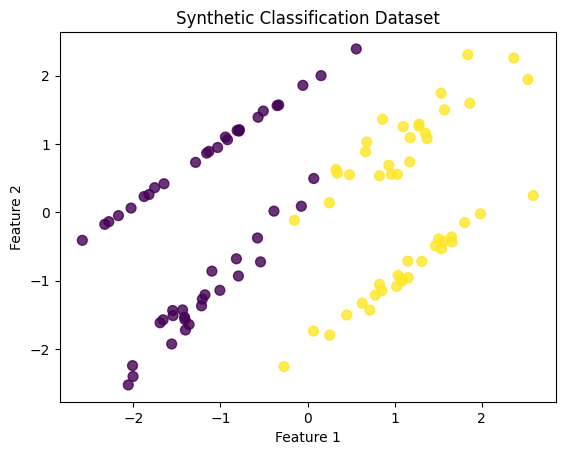

In [4]:
import matplotlib.pyplot as plt

# Assuming X has two features
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, alpha=0.8)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Synthetic Classification Dataset')
plt.show()


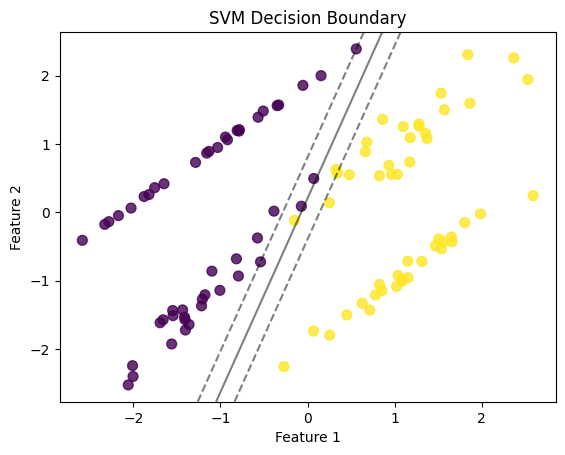

In [8]:
from sklearn.svm import SVC
from sklearn import metrics

svm = SVC(kernel='linear', C = 10) # vary the C here
svm.fit(X, y)

# Get the coefficients and intercept
coef = svm.coef_
intercept = svm.intercept_

# Plot decision boundary
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, alpha=0.8)
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = svm.decision_function(xy).reshape(XX.shape)

# plot decision boundary and margins
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM Decision Boundary')
plt.show()


In [9]:
support_vectors = svm.support_vectors_
print(support_vectors)

[[ 0.55942643  2.38869353]
 [ 0.07123641  0.49429823]
 [-0.07133524  0.08896214]
 [-0.53963044 -0.72427983]
 [-0.15013844 -0.11708689]
 [ 0.32725188  0.62453032]
 [ 0.34129395  0.57304248]]


In [10]:
svm.get_params(deep=True)

{'C': 10,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'linear',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

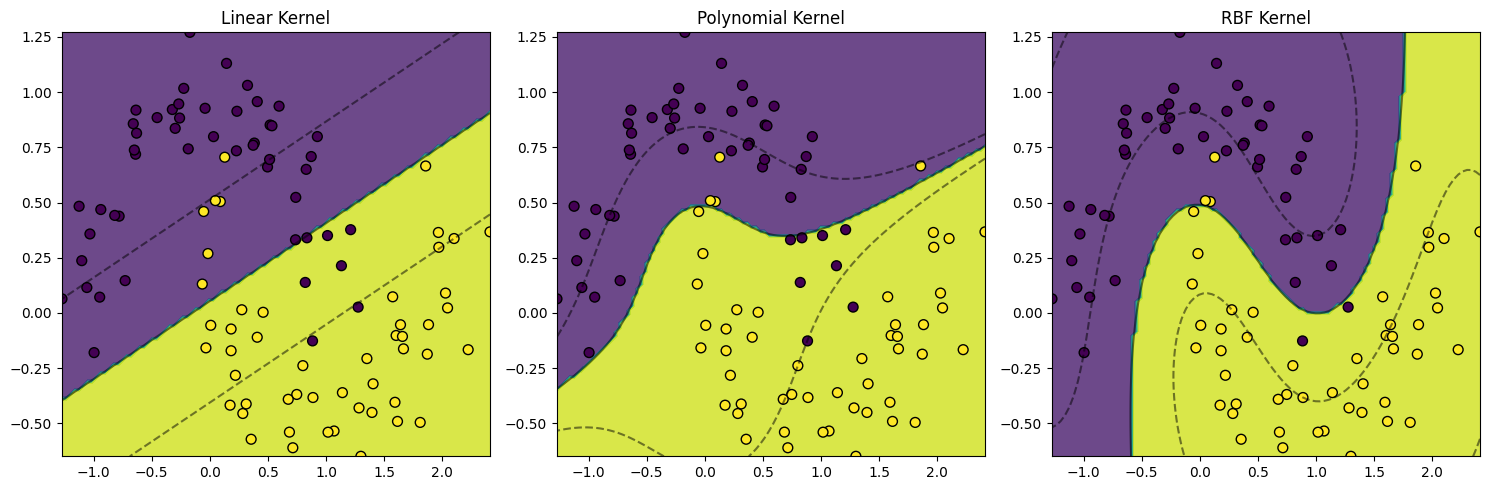

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_moons

# Generate a moon-shaped dataset for demonstration
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

# Define kernel types
kernels = ['linear', 'poly', 'rbf']
kernel_titles = ['Linear Kernel', 'Polynomial Kernel', 'RBF Kernel']

# Create subplots for each kernel
fig, axes = plt.subplots(1, len(kernels), figsize=(15, 5))

for i, kernel in enumerate(kernels):
    # Create an SVM classifier with the specified kernel
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X, y)

    # Plot the decision regions
    ax = axes[i]
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min(), X[:, 0].max(), 100),
                         np.linspace(X[:, 1].min(), X[:, 1].max(), 100))
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap='viridis', alpha=0.8)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, edgecolors='k', linewidth=1)

    # Plot decision boundaries
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100),
                         np.linspace(ylim[0], ylim[1], 100))
    Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

    ax.set_title(kernel_titles[i])

plt.tight_layout()
plt.show()


# Task-1 part2

### Stochastic Gradient Descent

We use stochastic gradient descent algorithm (SGD) for parameter optimization of SVM. Gradient Descent minimizes a function by following the gradients of the cost function. For further details see:

Wikipedia - stochastic gradient descent

### Calculating the Error 

To calculate the error of a prediction we first need to define the objective function of the svm. 

#### Hinge Loss Function

To do this, we need to define the loss function, to calculate the prediction error. We will use hinge loss for our perceptron:

$$c(x, y, f(x)) = (1 - y * f(x))_+$$

$c$ is the loss function, $x$ the sample, $y$ is the true label, $f(x)$ the predicted label.

This means the following:
$$
c(x, y, f(x))= 
\begin{cases}
    0,& \text{if } y*f(x)\geq 1\\
    1-y*f(x),              & \text{else}
\end{cases}
$$

So consider, if y and f(x) are signed values $(+1,-1)$:

<ul>
    <li>the loss is 0, if $y*f(x)$ are positive, respective both values have the same sign.</li>
    <li>loss is $1-y*f(x)$ if $y*f(x)$ is negative</li>
</ul>

#### Objective Function 

As we defined the loss function, we can now define the objective function for the svm:
$$\underset{w}{min}\ \lambda\parallel w\parallel^2 + \ \sum_{i=1}^n\big(1-y_i \langle x_i,w \rangle\big)_+$$

As you can see, our objective of a svm consists of two terms. The first term is a regularizer, the second term the loss. The regularizer balances between margin maximization and loss. To get more informations I advice you the tutorial introduction of the above adviced Schölkopf & Smola book.

#### Derive the Objective Function

To minimize this function, we need the gradients of this function.

As we have two terms, we will derive them seperately using the sum rule in differentiation.

$$
\frac{\delta}{\delta w_k} \lambda\parallel w\parallel^2 \ = 2 \lambda w_k
$$

$$
\frac{\delta}{\delta w_k} \big(1-y_i \langle x_i,w \rangle\big)_+ \ = \begin{cases}
    0,& \text{if } y_i \langle x_i,w \rangle\geq 1\\
    -y_ix_{ik},              & \text{else}
\end{cases}
$$

This means, if we have a misclassified sample $x_i$, respectively $y_i \langle x_i,w \rangle \ < \ 1$, we update the weight vector w using the gradients of both terms, if $y_i \langle x_i,w \rangle \geq 1$ we just update w by the gradient of the regularizer. To sum it up, our stochastic gradient descent for the svm looks like this:

if $y_i⟨x_i,w⟩ < 1$:
$$
w = w + \eta (y_ix_i - 2\lambda w)
$$
else:
$$
w = w + \eta (-2\lambda w)
$$

For simplicity's sake we fold the bias term into the data set:

This small toy data set contains two samples labeled with $-1$ and three samples labeled with $+1$. This means we have a binary classification problem, as the data set contains two sample classes. Lets plot the dataset to see, that is is linearly seperable:

#### The description of the code below line by line

line <b>2</b>: Initialize the weight vector for the perceptron with zeros<br>
line <b>3</b>: Set the learning rate to 1<br>
line <b>4</b>: Set the number of epochs<br>
line <b>6</b>: Iterate n times over the whole data set. The Iterator is begins with $1$ to avoid division by zero during regularization  parameter calculation<br>
line <b>7</b>: Iterate over each sample in the data set. <br>
line <b>8</b>: Misclassification condition $y_i \langle x_i,w \rangle < 1$<br>
line <b>9</b>: Update rule for the weights $w = w + \eta (y_ix_i - 2\lambda w)$ including the learning rate $\eta$ and the regularizer $\lambda$<br>
line <b>11</b>: If classified correctly just update the weight vector by the derived regularizer term $w = w + \eta (-2\lambda w)$.<br>

We will run the sgd $100000$ times. Our learning parameter $\eta$ is set to $1$. As a regulizing parameter $\lambda$, we choose $1/epoch$. So this parameter will decrease, as the number of epochs increases.

In [12]:
def svm_sgd(X, Y):
    w = np.zeros(len(X[0]))
    eta = 0.01
    epochs = 100000

    for epoch in range(1,epochs):
        for i, x in enumerate(X):
            if (Y[i]*np.dot(X[i], w)) < 1:
                w = w + eta * ( (X[i] * Y[i]) + (-2  *(1/epoch)* w) )
            else:
                w = w + eta * (-2  *(1/epoch)* w)

    return w

### Let the SVM learn! 

Next we can execute our code, to calculate the proper weight vector, which fits out training data. If there are misclassified samples we will print the number of misclassified and correctly classified samples.

# TASK-2

# MNIST Digits - Classification Using SVM

In this notebook, we'll explore the popular MNIST dataset and build an SVM model to classify handwritten digits. <a href='http://yann.lecun.com/exdb/mnist/'>Here is a detailed description of the dataset.</a>

This is a part of a kaggle competition - https://www.kaggle.com/c/digit-recognizer.

# Objective
We will develop a model using Support Vector Machine which should correctly classify the handwritten digits from 0-9 based on the pixel values given as features. Thus, this is a 10-class classification problem. 

# Data Description
For this problem, we use the MNIST data which is a large database of handwritten digits. The 'pixel values' of each digit (image) comprise the features, and the actual number between 0-9 is the label. 

 

Since each image is of 28 x 28 pixels, and each pixel forms a feature, there are 784 features. MNIST digit recognition is a well-studied problem in the ML community, and people have trained numerous models (Neural Networks, SVMs, boosted trees etc.) achieving error rates as low as 0.23% (i.e. accuracy = 99.77%, with a convolutional neural network).

 

Before the popularity of neural networks, though, models such as SVMs and boosted trees were the state-of-the-art in such problems.

We'll first explore the dataset a bit, prepare it (scale etc.) and then experiment with linear and non-linear SVMs with various hyperparameters.<br>

----------
We'll divide the analysis into the following parts:
- Data understanding and cleaning
- Data preparation for model building
- Building an SVM model - hyperparameter tuning, model evaluation etc.

#### NOTE:
Considering the **computational limitations** of the system and the data size at hand, to make our life easier we are going to use 50% of the available data set for model building.<br>

Final model can be extended to operate on the complete data set as well, considering appropirate computatinal power is available by the computing machine.


## Data Understanding and Cleaning
 
 Let's understand the dataset and see if it needs some cleaning etc.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
from sklearn.model_selection import train_test_split
import gc
import cv2

# read the dataset
digits = pd.read_csv("../src/data/train.csv")
digits.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [14]:
digits

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
# read the dataset
digits = pd.read_csv("../src/data/train.csv")
digits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [17]:
four = digits.iloc[3, 1:]
four.shape

(784,)

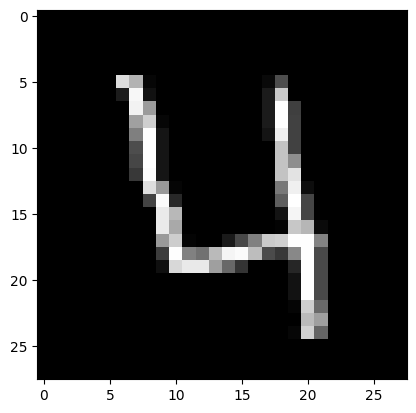

In [18]:
four = four.values.reshape(28, 28)
plt.imshow(four, cmap='gray')

In [19]:
# visualise the array
print(four[5:-5, 5:-5])

[[  0 220 179   6   0   0   0   0   0   0   0   0   9  77   0   0   0   0]
 [  0  28 247  17   0   0   0   0   0   0   0   0  27 202   0   0   0   0]
 [  0   0 242 155   0   0   0   0   0   0   0   0  27 254  63   0   0   0]
 [  0   0 160 207   6   0   0   0   0   0   0   0  27 254  65   0   0   0]
 [  0   0 127 254  21   0   0   0   0   0   0   0  20 239  65   0   0   0]
 [  0   0  77 254  21   0   0   0   0   0   0   0   0 195  65   0   0   0]
 [  0   0  70 254  21   0   0   0   0   0   0   0   0 195 142   0   0   0]
 [  0   0  56 251  21   0   0   0   0   0   0   0   0 195 227   0   0   0]
 [  0   0   0 222 153   5   0   0   0   0   0   0   0 120 240  13   0   0]
 [  0   0   0  67 251  40   0   0   0   0   0   0   0  94 255  69   0   0]
 [  0   0   0   0 234 184   0   0   0   0   0   0   0  19 245  69   0   0]
 [  0   0   0   0 234 169   0   0   0   0   0   0   0   3 199 182  10   0]
 [  0   0   0   0 154 205   4   0   0  26  72 128 203 208 254 254 131   0]
 [  0   0   0   0  61 254

In [20]:
# Summarise the counts of 'label' to see how many labels of each digit are present
digits.label.value_counts()

label
1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: count, dtype: int64

In [21]:
# Summarise count in terms of percentage
100*(round(digits.label.astype('category').value_counts()/len(digits.index), 4))

label
1    11.15
7    10.48
3    10.36
9     9.97
2     9.95
6     9.85
0     9.84
4     9.70
8     9.67
5     9.04
Name: count, dtype: float64

Thus, each digit/label has an approximately 9%-11% fraction in the dataset and the **dataset is balanced**. This is an important factor in considering the choices of models to be used, especially SVM, since **SVMs rarely perform well on imbalanced data** (think about why that might be the case).

Let's quickly look at missing values, if any.

In [22]:
# missing values - there are none
digits.isnull().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

In [23]:
# average values/distributions of features
description = digits.describe()
description

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


You can see that the max value of the mean and maximum values of some features (pixels) is 139, 255 etc., whereas most features lie in much lower ranges  (look at description of pixel 0, pixel 1 etc. above).

Thus, it seems like a good idea to rescale the features.

## Data Preparation for Model Building

Let's now prepare the dataset for building the model. We'll only use a fraction of the data else training will take a long time.


In [24]:
# Creating training and test sets
# Splitting the data into train and test
X = digits.iloc[:, 1:]
Y = digits.iloc[:, 0]

# Rescaling the features
from sklearn.preprocessing import scale
X = scale(X)

# train test split with train_size=10% and test size=90%
x_train, x_test, y_train, y_test = train_test_split(X, Y, train_size=0.10, random_state=101)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(4200, 784)
(37800, 784)
(4200,)
(37800,)


## Model Building

Let's now build the model and tune the hyperparameters. Let's start with a **linear model** first.

### Linear SVM

Let's first try building a linear SVM model (i.e. a linear kernel). 

In [25]:
%%time
from sklearn import svm
from sklearn import metrics

# an initial SVM model with linear kernel
svm_linear = svm.SVC(kernel='linear')

# fit
svm_linear.fit(x_train, y_train)

CPU times: total: 609 ms
Wall time: 595 ms


SVC(kernel='linear')

In [26]:
# predict
predictions = svm_linear.predict(x_test)
predictions[:10]

array([1, 3, 0, 0, 1, 9, 1, 5, 0, 6])

In [27]:
# evaluation: accuracy
# C(i, j) represents the number of points known to be in class i
# but predicted to be in class j
confusion = metrics.confusion_matrix(y_true = y_test, y_pred = predictions)
confusion

array([[3615,    0,   12,    8,    8,   28,   28,    5,    9,    2],
       [   0, 4089,   16,   23,    9,    3,    3,   13,   25,    4],
       [  54,   48, 3363,   64,   74,   13,   53,   52,   59,   10],
       [  20,   28,  121, 3387,    8,  175,    5,   54,   58,   44],
       [  12,   12,   26,    2, 3399,    7,   41,   41,    4,  158],
       [  49,   42,   32,  177,   41, 2899,   54,   14,   82,   28],
       [  36,   16,   55,    5,   34,   37, 3486,    3,   21,    0],
       [   9,   27,   37,   22,   70,   10,    4, 3619,   14,  142],
       [  26,   86,   71,  137,   24,  137,   29,   26, 3096,   33],
       [  38,   11,   39,   26,  182,   19,    1,  207,   27, 3228]])

In [28]:
# measure accuracy
metrics.accuracy_score(y_true=y_test, y_pred=predictions)

0.9042592592592592

In [29]:
# class-wise accuracy
class_wise = metrics.classification_report(y_true=y_test, y_pred=predictions)
print(class_wise)

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      3715
           1       0.94      0.98      0.96      4185
           2       0.89      0.89      0.89      3790
           3       0.88      0.87      0.87      3900
           4       0.88      0.92      0.90      3702
           5       0.87      0.85      0.86      3418
           6       0.94      0.94      0.94      3693
           7       0.90      0.92      0.91      3954
           8       0.91      0.84      0.88      3665
           9       0.88      0.85      0.87      3778

    accuracy                           0.90     37800
   macro avg       0.90      0.90      0.90     37800
weighted avg       0.90      0.90      0.90     37800



In [30]:
# run gc.collect() (garbage collect) to free up memory
# else, since the dataset is large and SVM is computationally heavy,
# it'll throw a memory error while training
gc.collect()

0

In [31]:
%%time

# rbf kernel with other hyperparameters kept to default
svm_rbf = svm.SVC(kernel='rbf')
svm_rbf.fit(x_train, y_train)

CPU times: total: 1.23 s
Wall time: 1.24 s


SVC()

In [32]:
# predict
predictions = svm_rbf.predict(x_test)

# accuracy
print(metrics.accuracy_score(y_true=y_test, y_pred=predictions))

0.9250793650793651


The accuracy achieved with a non-linear kernel is slightly higher than a linear one. Let's now do a grid search CV to tune the hyperparameters C and gamma.

### Grid Search Cross-Validation

In [33]:
%%time

# conduct (grid search) cross-validation to find the optimal values
# of cost C and the choice of kernel

from sklearn.model_selection import GridSearchCV

parameters = {'C':[1, 10, 100],
             'gamma': [1e-2, 1e-3, 1e-4]}

# instantiate a model
svc_grid_search = svm.SVC(kernel="rbf")

# create a classifier to perform grid search
clf = GridSearchCV(svc_grid_search, param_grid=parameters, scoring='accuracy')

# fit
clf.fit(x_train, y_train)

CPU times: total: 1min 32s
Wall time: 1min 32s


GridSearchCV(estimator=SVC(),
             param_grid={'C': [1, 10, 100], 'gamma': [0.01, 0.001, 0.0001]},
             scoring='accuracy')

In [34]:
# results
cv_results = pd.DataFrame(clf.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,2.385837,0.201864,1.136531,0.049201,1,0.0100,"{'C': 1, 'gamma': 0.01}",0.719048,0.759524,0.686905,0.733333,0.726190,0.725000,0.023450,9
1,0.713991,0.008147,0.678434,0.026787,1,0.0010,"{'C': 1, 'gamma': 0.001}",0.925000,0.921429,0.908333,0.911905,0.923810,0.918095,0.006709,3
2,1.020862,0.012402,1.020575,0.128591,1,0.0001,"{'C': 1, 'gamma': 0.0001}",0.876190,0.884524,0.866667,0.873810,0.883333,0.876905,0.006547,6
3,2.247859,0.055520,1.107947,0.030738,10,0.0100,"{'C': 10, 'gamma': 0.01}",0.733333,0.775000,0.709524,0.746429,0.744048,0.741667,0.021176,7
4,0.671287,0.020559,0.681113,0.034700,10,0.0010,"{'C': 10, 'gamma': 0.001}",0.941667,0.927381,0.915476,0.910714,0.930952,0.925238,0.011076,1
5,0.512736,0.008530,0.524802,0.023694,10,0.0001,"{'C': 10, 'gamma': 0.0001}",0.921429,0.925000,0.900000,0.910714,0.920238,0.915476,0.009066,4
6,2.333481,0.100140,1.152047,0.015051,100,0.0100,"{'C': 100, 'gamma': 0.01}",0.733333,0.775000,0.709524,0.746429,0.744048,0.741667,0.021176,7
7,0.668477,0.019503,0.628354,0.071353,100,0.0010,"{'C': 100, 'gamma': 0.001}",0.938095,0.929762,0.914286,0.908333,0.929762,0.924048,0.010999,2
8,0.423999,0.020367,0.424102,0.064137,100,0.0001,"{'C': 100, 'gamma': 0.0001}",0.908333,0.920238,0.886905,0.890476,0.923810,0.905952,0.015040,5


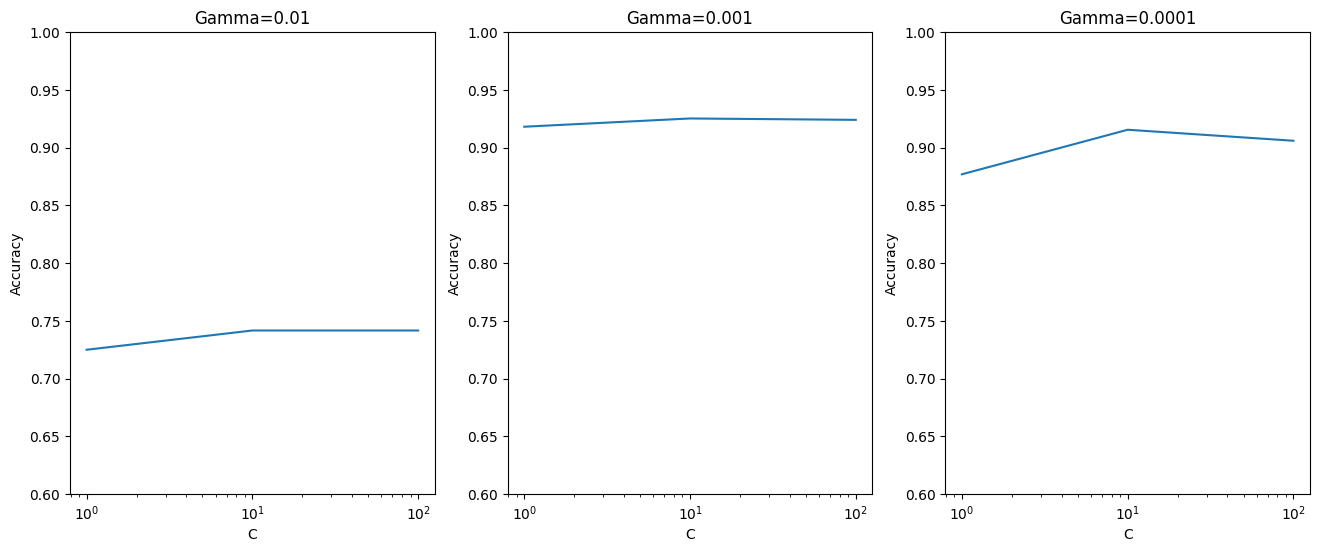

In [35]:
# converting C to numeric type for plotting on x-axis
cv_results['param_C'] = cv_results['param_C'].astype('int')

# # plotting
plt.figure(figsize=(16,6))

# subplot 1/3
plt.subplot(131)
gamma_01 = cv_results[cv_results['param_gamma']==0.01]

plt.plot(gamma_01["param_C"], gamma_01["mean_test_score"])
#plt.plot(gamma_01["param_C"], gamma_01["mean_train_score"])
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.title("Gamma=0.01")
plt.ylim([0.60, 1])
#plt.legend(['test accuracy', 'train accuracy'], loc='lower right')
plt.xscale('log')

# subplot 2/3
plt.subplot(132)
gamma_001 = cv_results[cv_results['param_gamma']==0.001]

plt.plot(gamma_001["param_C"], gamma_001["mean_test_score"])
#plt.plot(gamma_001["param_C"], gamma_001["mean_train_score"])
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.title("Gamma=0.001")
plt.ylim([0.60, 1])
#plt.legend(['test accuracy', 'train accuracy'], loc='lower right')
plt.xscale('log')


# subplot 3/3
plt.subplot(133)
gamma_0001 = cv_results[cv_results['param_gamma']==0.0001]

plt.plot(gamma_0001["param_C"], gamma_0001["mean_test_score"])
#plt.plot(gamma_0001["param_C"], gamma_0001["mean_train_score"])
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.title("Gamma=0.0001")
plt.ylim([0.60, 1])
#plt.legend(['test accuracy', 'train accuracy'], loc='lower right')
plt.xscale('log')

plt.show()

From the plot above, we can observe that (from higher to lower gamma / left to right):
- At very high gamma (0.01), the model is achieving 100% accuracy on the training data, though the test score is quite low (<75%). Thus, the model is overfitting.

- At gamma=0.001, the training and test scores are comparable at around C=1, though the model starts to overfit at higher values of C

- At gamma=0.0001, the model does not overfit till C=10 but starts showing signs at C=100. Also, the training and test scores are slightly lower than at gamma=0.001.

Thus, it seems that the best combination is gamma=0.001 and C=1 (the plot in the middle), which gives the highest test accuracy (~92%) while avoiding overfitting.

Let's now build the final model and see the performance on test data.

### Final Model

Let's now build the final model with chosen hyperparameters.

In [36]:
%%time

# optimal hyperparameters

best_C = 10
best_gamma = 0.001

# model
svm_final = svm.SVC(kernel='rbf', C=best_C, gamma=best_gamma)

# fit
svm_final.fit(x_train, y_train)

CPU times: total: 984 ms
Wall time: 959 ms


SVC(C=10, gamma=0.001)

In [37]:
%%time
# predict
predictions = svm_final.predict(x_test)

CPU times: total: 35.5 s
Wall time: 35.6 s


In [38]:
# evaluation: CM
confusion = metrics.confusion_matrix(y_true = y_test, y_pred = predictions)

# measure accuracy
test_accuracy = metrics.accuracy_score(y_true=y_test, y_pred=predictions)

print(test_accuracy, "\n")
print(confusion)


0.9318783068783069 

[[3615    0   10   12    4   12   38   11   11    2]
 [   0 4107   13   18    6    2    5   21    8    5]
 [  30   20 3438   60   37    4   37  112   41   11]
 [   8    9   92 3547    5   88    6   71   44   30]
 [   4   10   32    5 3460   11   33   46    3   98]
 [  22   21   12  114   20 3059   62   50   31   27]
 [  27    7   11    1    9   27 3548   47   16    0]
 [   5   22   21   11   49    4    2 3749   10   81]
 [  10   37   47   79   21   82   25   49 3290   25]
 [  15    7   18   28   97   12    0  174   15 3412]]


### KNN

In [39]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(4200, 784)
(37800, 784)
(4200,)
(37800,)


In [40]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

k_candidates = [3, 5, 7]
best_knn = None
best_acc = -1.0

print("\nTraining KNN ...")
for k in k_candidates:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(x_train, y_train)
    acc = accuracy_score(y_test, knn.predict(x_test))
    print(f"KNN(k={k}) test acc = {acc:.4f}")
    if acc > best_acc:
        best_acc = acc
        best_knn = knn

knn_y_pred = best_knn.predict(x_test)
knn_acc = accuracy_score(y_test, knn_y_pred)
print(f"\nBest KNN Test Accuracy: {knn_acc:.4f}")


Training KNN ...
KNN(k=3) test acc = 0.8856
KNN(k=5) test acc = 0.8875
KNN(k=7) test acc = 0.8849

Best KNN Test Accuracy: 0.8875


### K-means

In [41]:
from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment

print("\nRunning KMeans (k=10) ...")
kmeans = KMeans(n_clusters=10, random_state=42, n_init="auto")
kmeans.fit(x_train)

# 用训练好的聚类器预测测试集的簇
test_clusters = kmeans.predict(x_test)

# 用 Hungarian 将簇 ID 与真实标签做一一匹配，评估“聚类精度”
# 构造代价矩阵：cost[i,j] = - (#cluster==i 且 label==j)
conf_mat = np.zeros((10, 10), dtype=np.int64)
for c, t in zip(test_clusters, y_test):
    conf_mat[c, t] += 1

row_ind, col_ind = linear_sum_assignment(-conf_mat)  # 最大匹配
cluster2label = {row: col for row, col in zip(row_ind, col_ind)}
mapped_preds = np.array([cluster2label[c] for c in test_clusters], dtype=np.int64)
kmeans_acc = accuracy_score(y_test, mapped_preds)

print(f"KMeans (Hungarian-mapped) Test Accuracy: {kmeans_acc:.4f}")


Running KMeans (k=10) ...
KMeans (Hungarian-mapped) Test Accuracy: 0.4420


## Extensive Task

In [42]:
# ---------- 1) 逻辑回归（多类Softmax） ----------
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("\nTraining Logistic Regression ...")
lr = LogisticRegression(max_iter=200, n_jobs=-1, solver="lbfgs", multi_class="multinomial", C=2.0)
lr.fit(x_train, y_train)
lr_acc = accuracy_score(y_test, lr.predict(x_test))
print(f"Logistic Regression acc: {lr_acc:.4f}")

# ---------- 2) 多层感知机（MLP） ----------
from sklearn.neural_network import MLPClassifier
print("\nTraining MLP ...")
mlp = MLPClassifier(hidden_layer_sizes=(256, 128),
                    activation="relu",
                    solver="adam",
                    learning_rate_init=1e-3,
                    batch_size=256,
                    max_iter=20,
                    random_state=42,
                    verbose=False)
mlp.fit(x_train, y_train)
mlp_acc = accuracy_score(y_test, mlp.predict(x_test))
print(f"MLP acc: {mlp_acc:.4f}")

# ---------- 3) 随机森林 ----------
from sklearn.ensemble import RandomForestClassifier
print("\nTraining RandomForest ...")
rf = RandomForestClassifier(n_estimators=200, max_depth=None, n_jobs=-1, random_state=42)
rf.fit(x_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(x_test))
print(f"RandomForest acc: {rf_acc:.4f}")

print("\n=== Extended Models Summary (sklearn) ===")
print(f"LogReg    : {lr_acc:.4f}")
print(f"MLP       : {mlp_acc:.4f}")
print(f"RandForest: {rf_acc:.4f}")


Training Logistic Regression ...


d:\MyApplication\Anaconda\envs\ml_lab1\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression acc: 0.8763

Training MLP ...


d:\MyApplication\Anaconda\envs\ml_lab1\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP acc: 0.9312

Training RandomForest ...
RandomForest acc: 0.9347

=== Extended Models Summary (sklearn) ===
LogReg    : 0.8763
MLP       : 0.9312
RandForest: 0.9347


# ANSWER:
RandForest-can achieve better results when resources are extremely limited